In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
%matplotlib inline

Proposed Attention-based Motif Discovery Pipeline for dnabert
1. Calculate attention scores extracted from finetuned model on Rand_Neg dataset and load attention scores 
extracted for the [CLS] token from the final hidden layer.
2. Visualized scores in base-pair resolution to see common trends to find thresholds for defining high peaks
3. Extract all fragments around top peaks for all positive(origin sequences) (or true positives)
4. Save fragments of 20 bps around peaks in .fasta file for motif Discovery by MEME

In [2]:
atten_path= "/data/OriDB_random_neg/train_dev_test_oridb50/4" # specify the path to attention scores calculated by DNABERT Visualization module
data_dir="/data/OriDB_random_neg/train_dev_test_oridb50" # specify the path to the directory that contains data you want to used for motif discovery pipeline, train(or test)
atten_scores = np.load(os.path.join(atten_path,"atten.npy"))
print(atten_scores.shape)
data = pd.read_csv(os.path.join(data_dir,"train_window.tsv"),sep='\t',header=0) # .bed file or .tsv file that contains genomic coordinates of sequences used for attention score calculation
seq_data = pd.read_csv(os.path.join(data_dir,"train.tsv"), sep='\t', header=0) #corresponding sequences file
data['seq'] = seq_data['sequence']
print(data)


(455, 500)
     chr   start     end                                                seq  \
0      9    7935    8434  TCACTGAGCTATAATACGGTAGTGGCTCGCACTCATGCGGGGGCTA...   
1     16   73009   73508  AGTACACTGGTCAGGAAATGGTGCTTTTGCGAGGAGAATGTGTGTG...   
2      9   33332   33831  TTCTTCACACCGGATTAAACAAAAAAACTGTGTTAATCGGATCCGG...   
3     13  158800  159299  TTGACGATGTCGTCCTACAAGACACTTTGTGCTCAATGAGCAACCG...   
4     13  363312  363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
..   ...     ...     ...                                                ...   
450    4  388068  388567  AAATTCTCCAACTACCTTGGCCACGTATTCCTTAGTGACTTCTCGA...   
451   15  566278  566777  CAATTTATACATGAAATGCTCCATAATATTGTCCATTTAGTTCTTA...   
452   12  126014  126513  AATCCATTACAGAATCTAATCTTATCGGAAGACTTGACATTAGTTG...   
453   13  713451  713950  GCTTATTGGATGATTGCCAGACCTTAAAAGGAGTTCTTACTTGCTT...   
454    8  245498  245997  TACATAACTGGACCGAAGAGTTATTGGGAAAGAAGAAAGAAGCATG...   

     label  
0        0  
1        1  
2

In [3]:
# Split data into positive and negative samples

pos = data[data['label'] == 1]
neg = data[data['label'] == 0]
pos_atten_scores = atten_scores[pos.index.values]
neg_atten_scores = atten_scores[neg.index.values]
pos.reset_index(drop=True, inplace=True)
neg.reset_index(drop=True, inplace=True)
print(pos)


     chr    start      end                                                seq  \
0     16    73009    73508  AGTACACTGGTCAGGAAATGGTGCTTTTGCGAGGAGAATGTGTGTG...   
1      9    33332    33831  TTCTTCACACCGGATTAAACAAAAAAACTGTGTTAATCGGATCCGG...   
2     13   158800   159299  TTGACGATGTCGTCCTACAAGACACTTTGTGCTCAATGAGCAACCG...   
3      4   212322   212821  TTCTGATTTTAGTGGAAAAACTTTCGAAACTTAAAATAATAATAGC...   
4     10   442190   442689  CTGGATTATTCCTAATAATTTGTTTGATGGCGGGAAGTGAAGGTTT...   
..   ...      ...      ...                                                ...   
223   13    39916    40415  ATCTCAACATGCAACTAGTAATAGTACAATTTTTAGTACCCTTTAA...   
224    5   212272   212771  ATCTTTATCTTTTTCATCCGTATTATGTAAACCTGAATAGCCCCTT...   
225   12  1023709  1024208  CGGGCGAGGCTGAACTGATGAGAAACAGTGATACTATGGCAACAAT...   
226   15   566278   566777  CAATTTATACATGAAATGCTCCATAATATTGTCCATTTAGTTCTTA...   
227    8   245498   245997  TACATAACTGGACCGAAGAGTTATTGGGAAAGAAGAAAGAAGCATG...   

     label  
0        1  
1

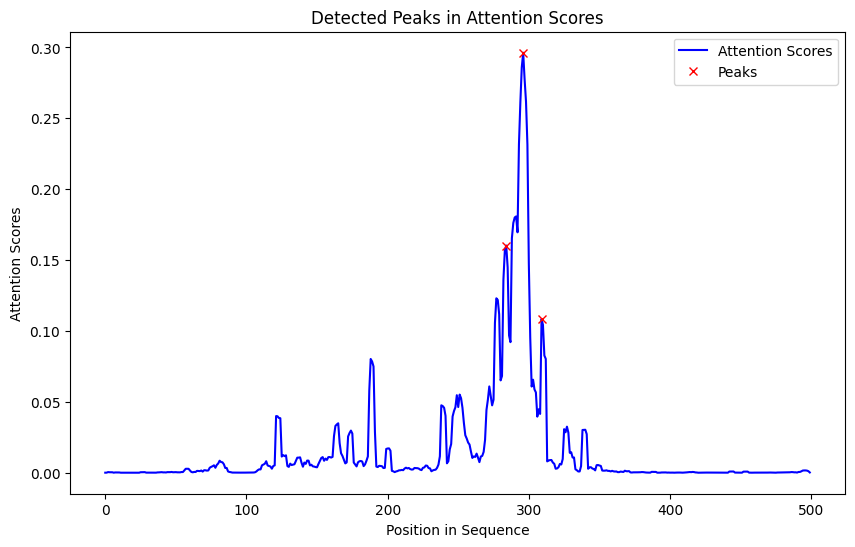

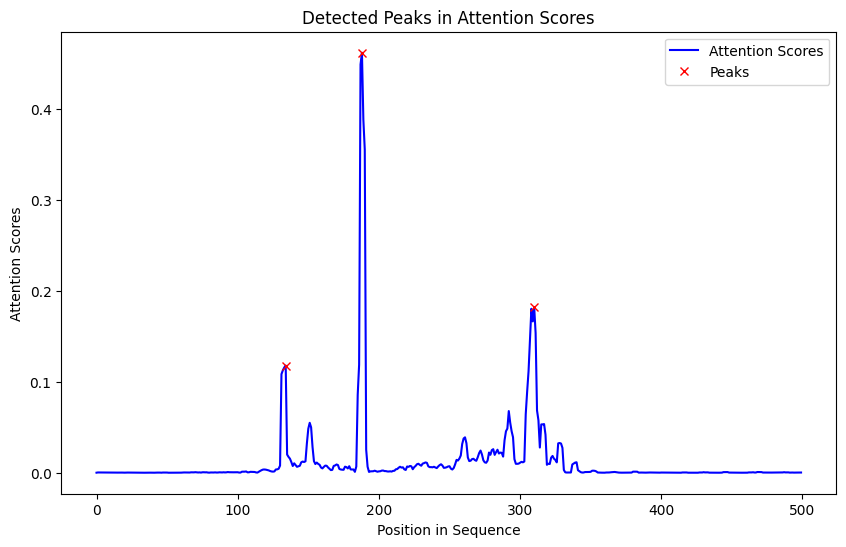

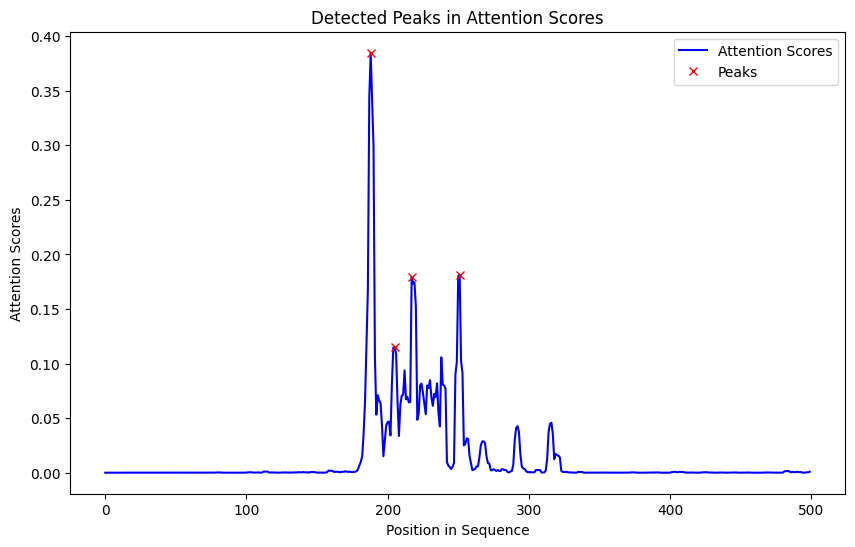

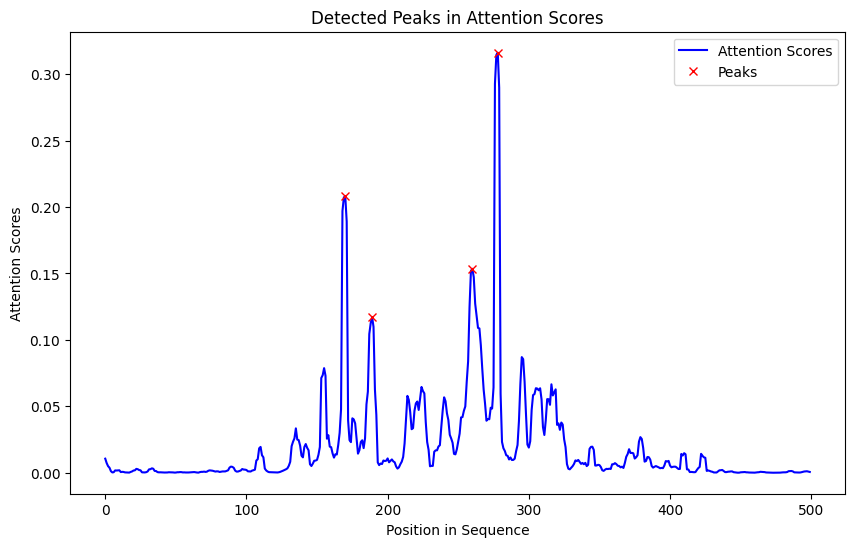

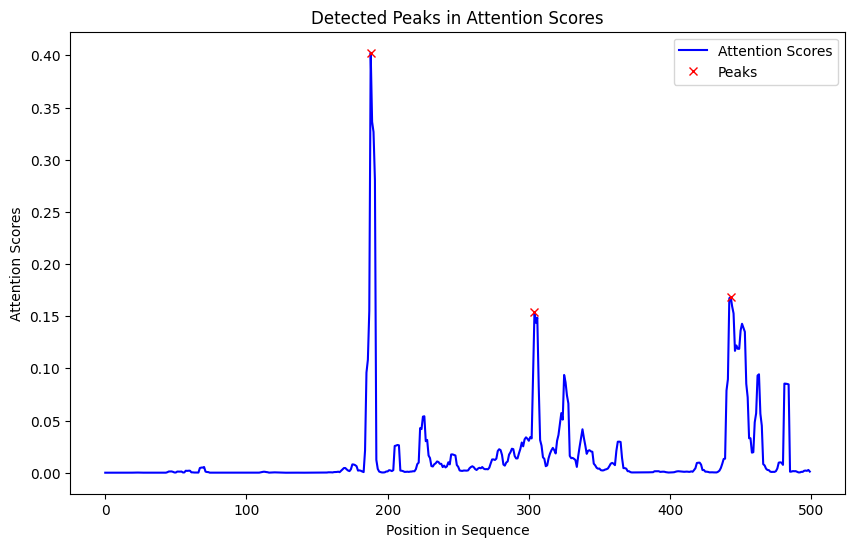

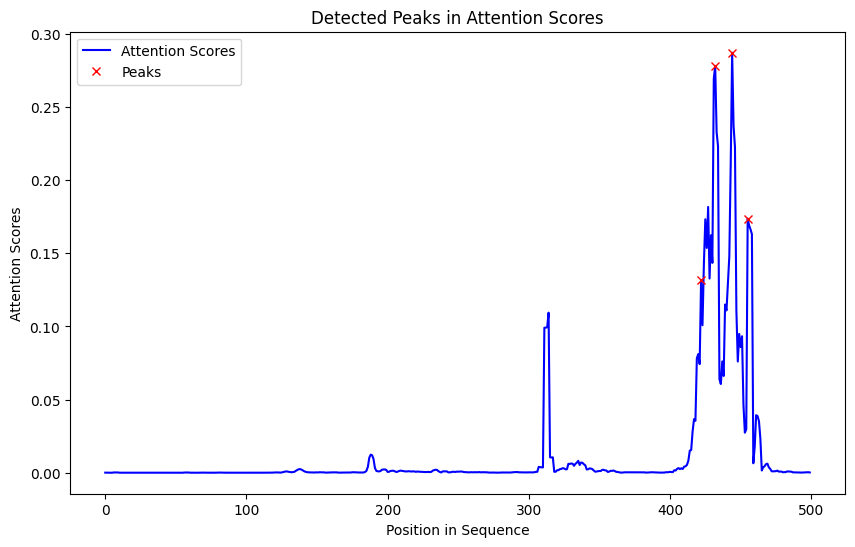

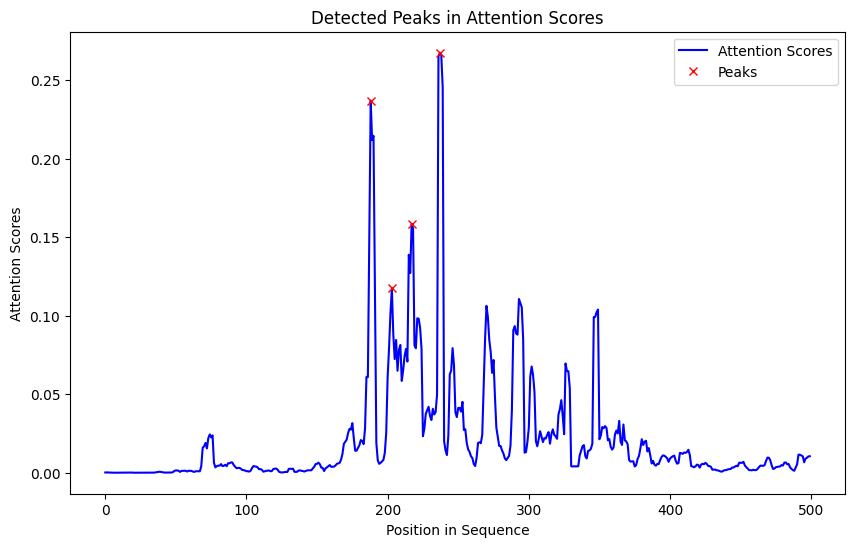

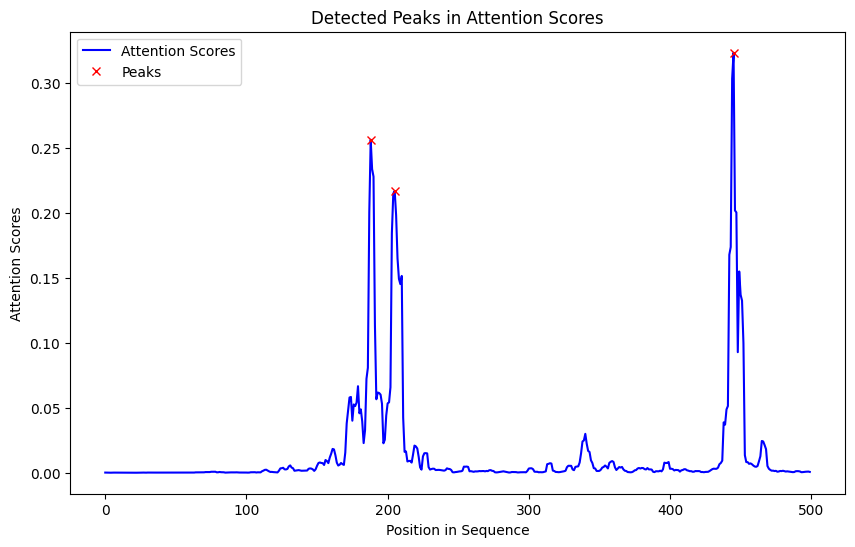

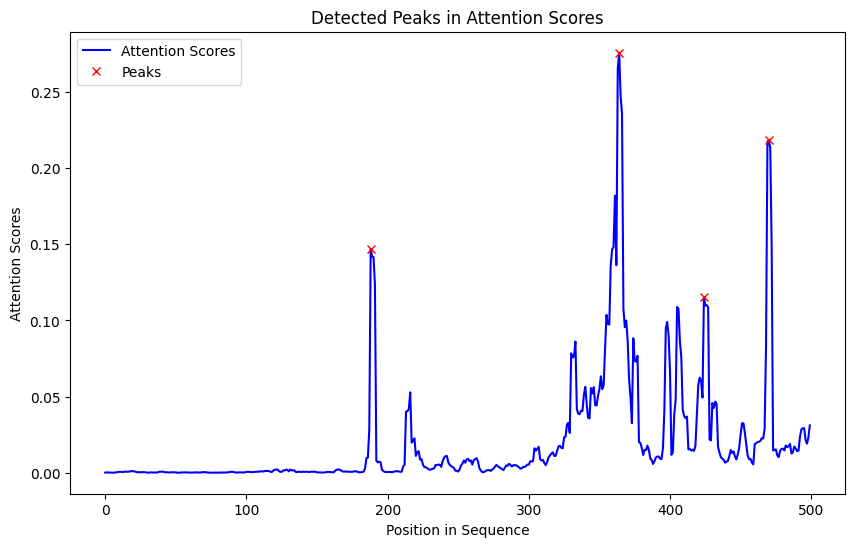

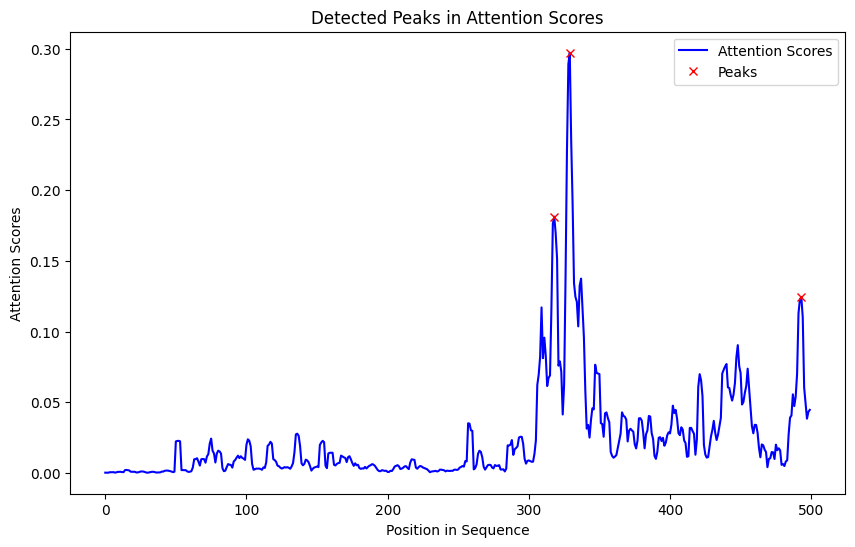

In [5]:

# visualize some of the sequences to see common trends to find thresholds for selecting peaks in attention scores

# thresholds for peak selection
top_n=4
att_score_threshold=0.1

for index, row in pos.iterrows():
    if index <10: 
        scores= pos_atten_scores[index]
        
        
        x = range(len(row['seq']))
        y = scores

        
        peaks, properties = find_peaks(y, height= att_score_threshold, distance=10)
        peak_scores = properties["peak_heights"]
    
        # Sort peaks by score descending and take top_n
        top_indices = np.argsort(peak_scores)[::-1][:top_n]
        top_peaks = peaks[top_indices]

     
        plt.figure(figsize=(10, 6))
        plt.plot(x, y, label='Attention Scores', color='blue')
        plt.plot(top_peaks, y[top_peaks], 'x', label='Peaks', color='red')
        
        plt.title('Detected Peaks in Attention Scores')
        plt.xlabel('Position in Sequence')
        plt.ylabel('Attention Scores')
        plt.legend()
        plt.show()
        


In [8]:
# Extract all fragments around top peaks for all positive sequences based on thresholds and save it in fasta format

all_fragments={}
# thresholds for peak selection
top_n=4
att_score_threshold=0.1

for index, row in pos.iterrows():
    
        scores= pos_atten_scores[index]
        
        
        x = range(len(row['seq']))
        y = scores

        
        peaks, properties = find_peaks(y, height= att_score_threshold, distance=10)
        peak_scores = properties["peak_heights"]
    
        # Sort peaks by score descending and take top_n
        top_indices = np.argsort(peak_scores)[::-1][:top_n]
        top_peaks = peaks[top_indices]
        
        peak_motifs = {
            "Seq" + str(index) + "Pos" + str(i): row["seq"][i-10:i+10]
            for i in top_peaks if len(row["seq"][i-10:i+10]) >= 20
        }
        all_fragments.update(peak_motifs)
        
all_fragments

{'Seq0Pos296': 'TAAATATATATATATAGATT',
 'Seq0Pos284': 'TAATTATAATTATAAATATA',
 'Seq0Pos309': 'ATAGATTATTCACAGGAGAA',
 'Seq1Pos188': 'ATGATCAGGTTTGCGATCCT',
 'Seq1Pos310': 'AAACATTATATAACAGACAT',
 'Seq1Pos134': 'ACACCTATTTATTAATAAAT',
 'Seq2Pos188': 'TCTTTTTTTTTGTAGGCCAA',
 'Seq2Pos251': 'AGATATGTTTTTATGTTTAG',
 'Seq2Pos217': 'AGAACAATAGATTATAAATA',
 'Seq2Pos205': 'CAATGATAGGAAAGAACAAT',
 'Seq3Pos278': 'AAAAAAATGATAAGCAGGAT',
 'Seq3Pos170': 'TAAACCATTATATAGGTCAA',
 'Seq3Pos260': 'CCAACAACAAAATATAAAAA',
 'Seq3Pos189': 'ATTAATATATTTATAGATCA',
 'Seq4Pos188': 'GATAACATTCTGCGATAGAG',
 'Seq4Pos443': 'ATTTTTTCATCTACTTACTT',
 'Seq4Pos304': 'TTGAATGAGATATGAGAGAG',
 'Seq5Pos444': 'TCATATACAATATAAGAAGA',
 'Seq5Pos432': 'ACTAATATATTATCATATAC',
 'Seq5Pos455': 'ATAAGAAGATGTCATAAACA',
 'Seq5Pos422': 'CTGTCATACTACTAATATAT',
 'Seq6Pos237': 'AAAATACTGGGCAATAAGGC',
 'Seq6Pos188': 'ACTCAATTTCGTCAAGATTT',
 'Seq6Pos217': 'GTACAATCCATACAGTTAAC',
 'Seq6Pos203': 'GATTTTTTTTACTAGTACAA',
 'Seq7Pos445': 'ACAAATATA

In [11]:


with open('motif_discovery/fragments_train_pos.fasta', 'w') as file:
    for key, value in all_fragments.items():
        file.write(f'>{key}\n{value}\n')


In [ ]:
# use motif discovery tools like MEME to find motifs in fasta file